**MAIN GOAL** : Cluster loyal versus disengaged customers by behavioral and financial 
attributes. Mine rules such as: customers from Germany holding only one 
product who are inactive represent a strong churn profile. Detect anomalies 
in sudden balance drops preceding account closure.


# Phase 1 : Data Understanding and Preprocessing


P1 Goal : Produce a clean, analysis-ready dataset and document every preprocessing 
decision with justification. This phase establishes the factual foundation for all 
subsequent mining steps

## EDA

### Importing libraries and loading dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/churn.csv')

### Data Types and Missing Values

In [3]:
# data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
# missing value
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Check unique values for object data

In [6]:
print( "Surname Unique counts:", df['Surname'].value_counts())


Surname Unique counts: Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
            ..
Izmailov     1
Bold         1
Bonham       1
Poninski     1
Burbidge     1
Name: count, Length: 2932, dtype: int64


In [7]:
print("Geography Unique counts:", df['Geography'].value_counts())

Geography Unique counts: Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [8]:
print("Gender counts:", df['Gender'].value_counts())

Gender counts: Gender
Male      5457
Female    4543
Name: count, dtype: int64


### Outlier detection

In [9]:
# Note: We identify outliers but do not drop them here, as Phase 4 
# requires cross-referencing anomalies with Phase 2 cluster outliers.

numeric_cols = df.select_dtypes(include=['number']).columns
cols_to_check = [col for col in numeric_cols if col not in ['RowNumber', 'CustomerId']]

def detect_outliers_iqr(data, columns):
    outlier_indices = []
    
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
        outlier_indices.extend(outliers)
        
        print(f"Column: {col} | Outliers detected: {len(outliers)}")
        
    return list(set(outlier_indices))

outlier_list = detect_outliers_iqr(df, cols_to_check)
outlier_df = df.loc[outlier_list]

Column: CreditScore | Outliers detected: 15
Column: Age | Outliers detected: 359
Column: Tenure | Outliers detected: 0
Column: Balance | Outliers detected: 0
Column: NumOfProducts | Outliers detected: 60
Column: HasCrCard | Outliers detected: 0
Column: IsActiveMember | Outliers detected: 0
Column: EstimatedSalary | Outliers detected: 0
Column: Exited | Outliers detected: 2037


### Graph Distribution of numerical features

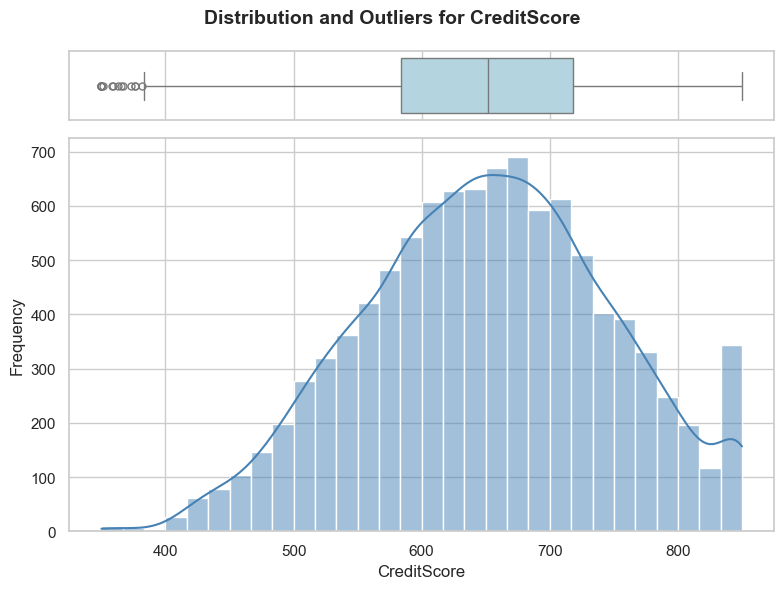

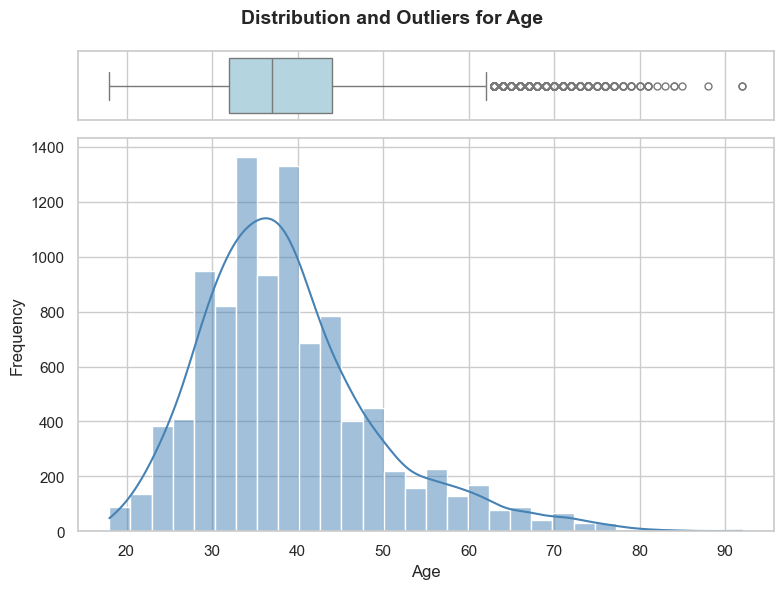

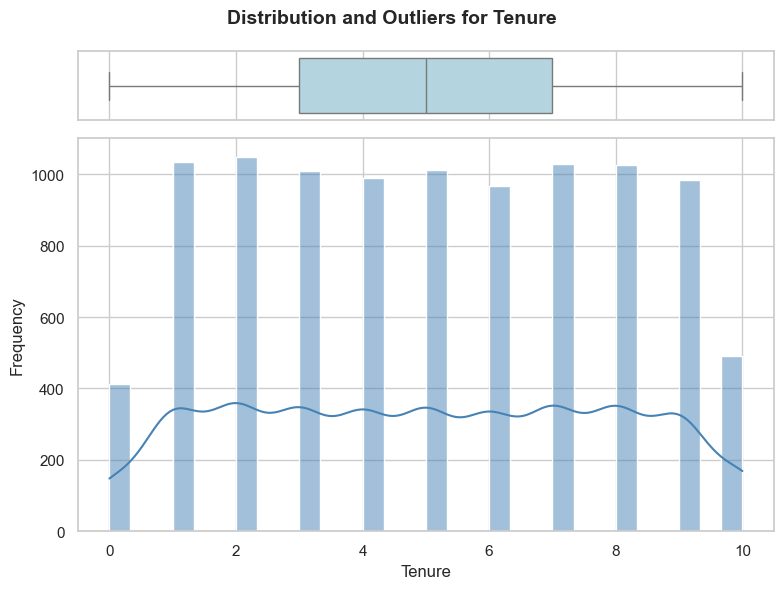

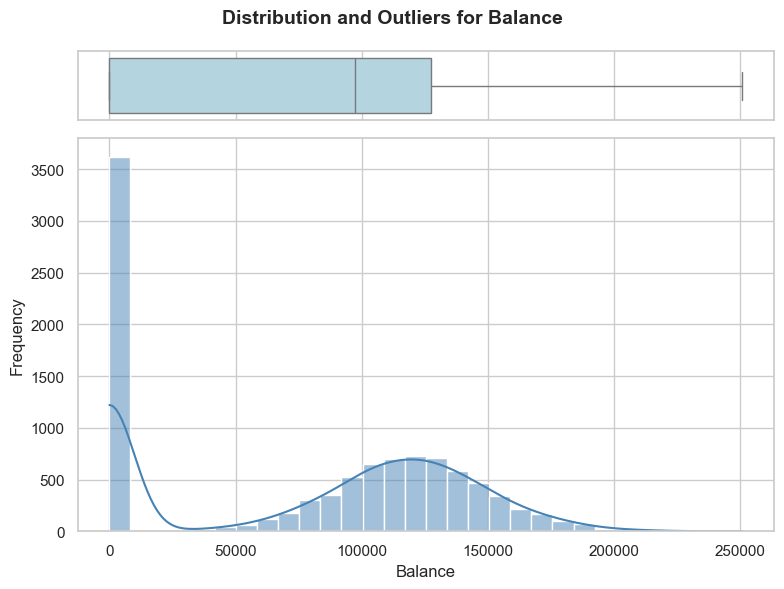

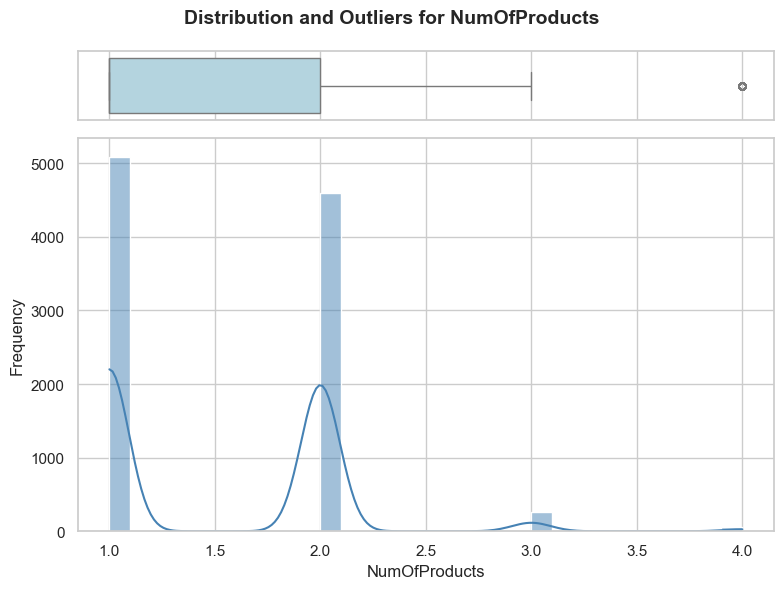

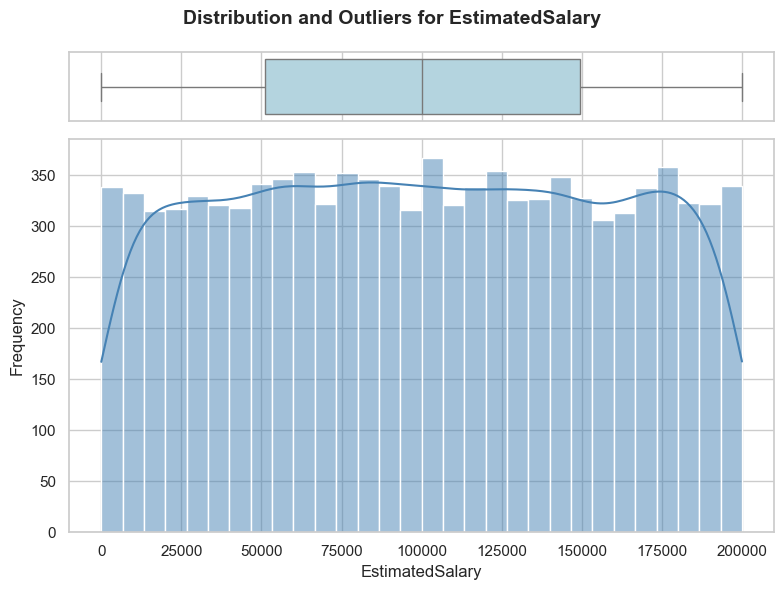

In [10]:
# 1. Define your numerical columns (excluding IDs and binary flags)
cols_to_check = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# 2. Set the visual style
sns.set_theme(style="whitegrid")

# 3. Loop through each column and create a combined graph
for col in cols_to_check:
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(8, 6))
    
    sns.boxplot(x=df[col], ax=ax_box, color='lightblue', flierprops=dict(marker='o', color='red', markersize=5))
    sns.histplot(data=df, x=col, kde=True, ax=ax_hist, color='steelblue', bins=30)
    
    ax_box.set(xlabel='') 
    ax_hist.set(xlabel=col, ylabel='Frequency')
    
    plt.suptitle(f'Distribution and Outliers for {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Graph Count of object features

C:\Users\Thomas\AppData\Local\Temp\ipykernel_175948\2446648625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


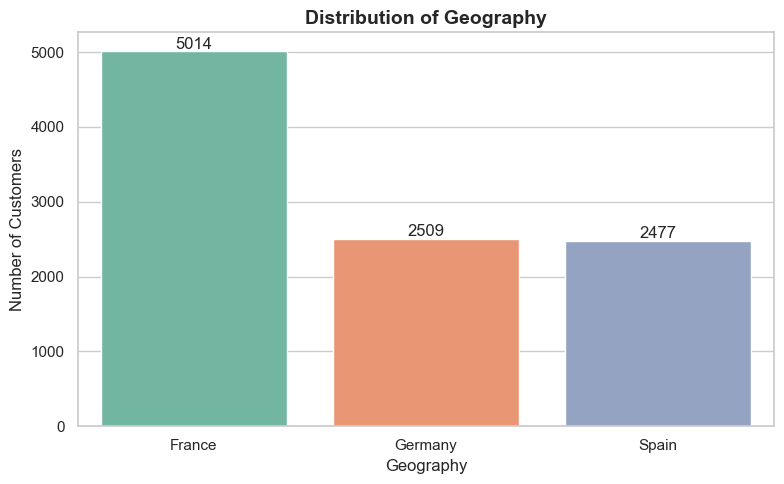

C:\Users\Thomas\AppData\Local\Temp\ipykernel_175948\2446648625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


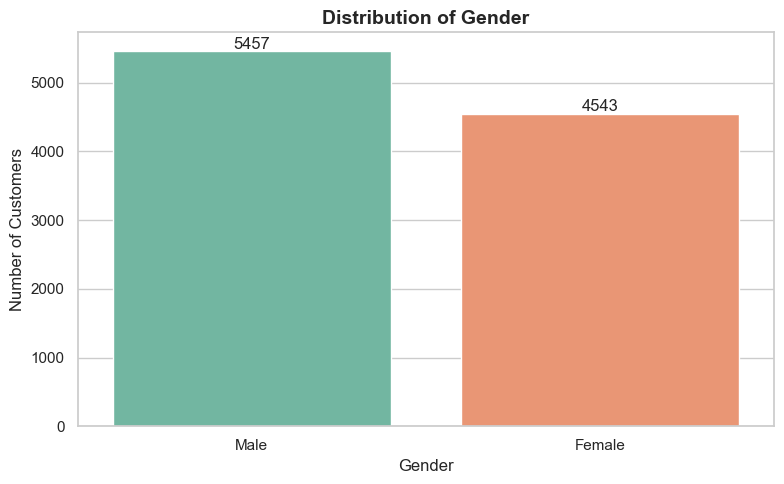

In [11]:
object_cols = df.select_dtypes(include=['object']).columns
cols_to_exclude = ['RowNumber', 'CustomerId', 'Surname']
cols_to_plot = [col for col in object_cols if col not in cols_to_exclude]

sns.set_theme(style="whitegrid")

for col in cols_to_plot:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
    
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

## Apply data cleaning

In [12]:
print("Duplicates before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()

print("Missing values before cleaning:\n", df.isna().sum())
df = df.dropna()

columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print("Shape after data cleaning:", df.shape)


Duplicates before cleaning: 0
Missing values before cleaning:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Shape after data cleaning: (10000, 11)


In [13]:
zero_age_count = (df['Age'] == 0).sum()
print(f"Number of customers with Age 0: {zero_age_count}")

Number of customers with Age 0: 0


## Perform data transformation: normalization, encoding, and binning of continuous variables

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder

# 1. Binning: Creating categorical groups for Phase 3 Association Rules
if 'Age' in df.columns:
    df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 50, 60, 150], labels=['Youth', 'Adult', 'Senior', 'Elderly'])

# 2. Separate Target
X = df.drop('Exited', axis=1)
y = df['Exited']

# 3. Define Transformers
numeric_cols = ['CreditScore', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts', 'Age']
categorical_cols = ['Geography', 'AgeGroup']
binary_cols = ['Gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_cols), 
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols), 
        ('bin', OrdinalEncoder(), binary_cols) 
    ],
    remainder='passthrough' 
)

# 4. Transform ENTIRE dataset (No train_test_split for unsupervised KDD)
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

X_clean = pd.DataFrame(
    pipeline.fit_transform(X), 
    columns=pipeline.get_feature_names_out()
)

print(X_clean.head())

   num__CreditScore  num__Balance  num__EstimatedSalary  num__Tenure  \
0         -0.246269     -0.761480              0.011739        -0.75   
1         -0.328358     -0.104906              0.125512        -1.00   
2         -1.119403      0.489346              0.139630         0.75   
3          0.350746     -0.761480             -0.064717        -1.00   
4          1.477612      0.221806             -0.214561        -0.75   

   num__NumOfProducts  num__Age  cat__Geography_Germany  cat__Geography_Spain  \
0                 0.0  0.416667                     0.0                   0.0   
1                 0.0  0.333333                     0.0                   1.0   
2                 2.0  0.416667                     0.0                   0.0   
3                 1.0  0.166667                     0.0                   0.0   
4                 0.0  0.500000                     0.0                   1.0   

   cat__AgeGroup_Elderly  cat__AgeGroup_Senior  cat__AgeGroup_Youth  \
0        

## Conduct feature selection using correlation analysis and entropy measures

### Heatmap of correlation between numerical features and entropy

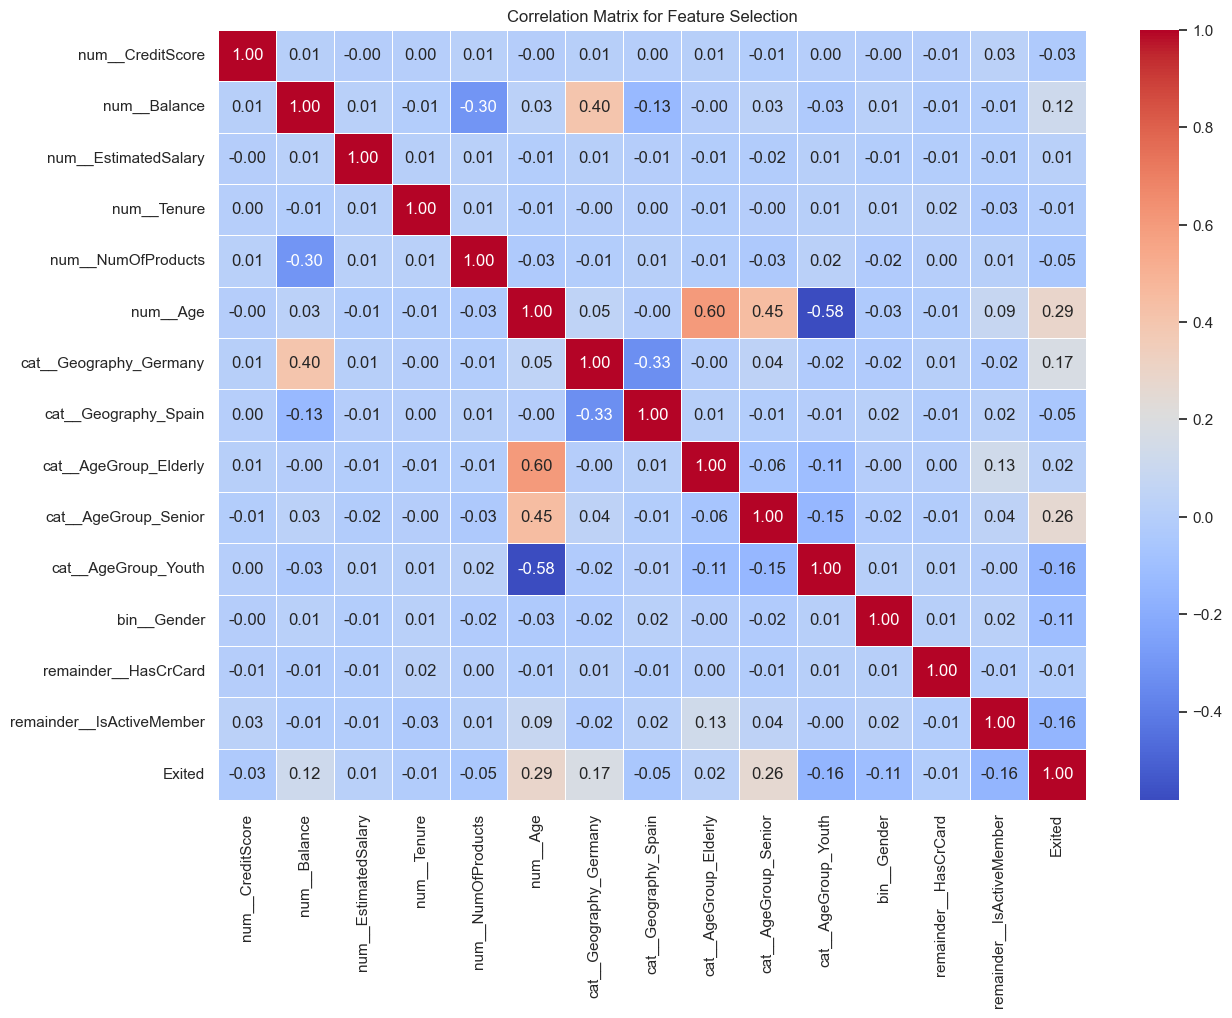


Features correlated with target ('Exited'):
 Exited                       1.000000
num__Age                     0.285323
cat__AgeGroup_Senior         0.261884
cat__Geography_Germany       0.173488
cat__AgeGroup_Youth          0.157928
remainder__IsActiveMember    0.156128
num__Balance                 0.118533
bin__Gender                  0.106512
cat__Geography_Spain         0.052667
num__NumOfProducts           0.047820
num__CreditScore             0.027094
cat__AgeGroup_Elderly        0.024178
num__Tenure                  0.014001
num__EstimatedSalary         0.012097
remainder__HasCrCard         0.007138
Name: Exited, dtype: float64

Information Gain (Entropy-based) for Feature Selection:
 num__NumOfProducts           0.075019
num__Age                     0.070925
cat__AgeGroup_Senior         0.025651
cat__AgeGroup_Youth          0.017388
cat__Geography_Germany       0.017131
remainder__IsActiveMember    0.014252
cat__AgeGroup_Elderly        0.008679
num__Balance                 0.

In [15]:
from sklearn.feature_selection import mutual_info_classif

# 1. Re-attach target for analysis
analysis_df = X_clean.copy()
analysis_df['Exited'] = y.values

# 2. Pearson Correlation
plt.figure(figsize=(14, 10))
correlation_matrix = analysis_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Feature Selection")
plt.show()

if 'Exited' in correlation_matrix.columns:
    target_corr = correlation_matrix['Exited'].abs().sort_values(ascending=False)
    print("\nFeatures correlated with target ('Exited'):\n", target_corr)
    
# 3. Entropy-based Feature Selection (Information Gain / Mutual Information)
mi_scores = mutual_info_classif(X_clean, y, random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X_clean.columns)
mi_scores = mi_scores.sort_values(ascending=False)

print("\nInformation Gain (Entropy-based) for Feature Selection:\n", mi_scores)

#### Checking for imbalanced in 'Exited' variable

In [ ]:
# Check imbalance in Exited
df['Exited'].value_counts(normalize=True)



Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## Deliverable: Clean dataset file and Preprocessing Report

In [17]:
import os

# Re-attach target variable for Phase 2 and 3
final_clean_df = X_clean.copy()
final_clean_df['Exited'] = y.values 

# Define the path relative to your notebooks/ folder
output_dir = '../data/processed/'

# Create the directory if it doesn't already exist
os.makedirs(output_dir, exist_ok=True)

# Save the single unified dataset
filepath = os.path.join(output_dir, 'churn_clean.csv')
final_clean_df.to_csv(filepath, index=False)

print(f"Phase 1 execution complete.")
print(f"Cleaned dataset saved successfully to '{filepath}'.")

Phase 1 execution complete.
Cleaned dataset saved successfully to '../data/processed/churn_clean.csv'.


# Phase 2: Segmentation via Clustering

## Apply K-Means clustering to segment entities by behavioral or financial attributes

In [18]:
# ── Phase 2 ─ K-Means Clustering ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# churn_clean.csv already has scaled/encoded features from Phase 1 pipeline
df_clean = pd.read_csv('../data/processed/churn_clean.csv')

# Drop the target before clustering (unsupervised)
feature_cols = [c for c in df_clean.columns if c != 'Exited']
X_scaled = df_clean[feature_cols].values

# K-Means with k=4 (justified by Elbow/Silhouette below)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df_clean['KMeans_Cluster'])
print(f'K-Means Silhouette Score (k=4): {sil:.4f}')
print('Cluster distribution:')
print(df_clean['KMeans_Cluster'].value_counts().sort_index())


K-Means Silhouette Score (k=4): 0.1107
Cluster distribution:
KMeans_Cluster
0    3358
1    1967
2    3393
3    1282
Name: count, dtype: int64


## Use DBSCAN to identify outlier profiles and noise points within the data

In [19]:
# ── Phase 2 ─ DBSCAN Outlier / Noise Detection ───────────────────────────────
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10)
df_clean['DBSCAN_Label'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df_clean['DBSCAN_Label'])) - (1 if -1 in df_clean['DBSCAN_Label'].values else 0)
n_noise       = (df_clean['DBSCAN_Label'] == -1).sum()

print(f'DBSCAN clusters found : {n_clusters_db}')
print(f'Noise / outlier points: {n_noise} ({n_noise/len(df_clean)*100:.2f}%)')
print('Label distribution:')
print(df_clean['DBSCAN_Label'].value_counts().sort_index())


DBSCAN clusters found : 1
Noise / outlier points: 76 (0.76%)
Label distribution:
DBSCAN_Label
-1      76
 0    9924
Name: count, dtype: int64


## Apply Hierarchical clustering and compare dendrograms across linkage methods

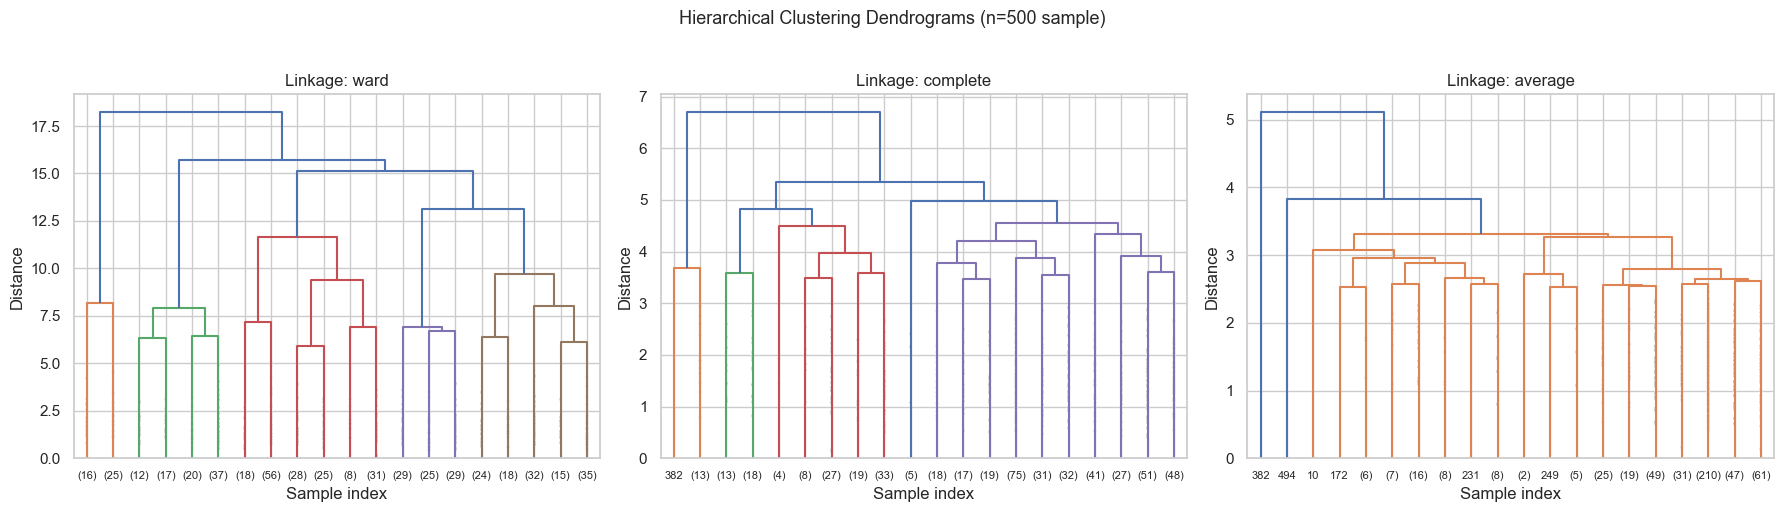

Hierarchical cluster label counts (ward, k=4, on sample):
1     41
2     86
3    166
4    207
Name: count, dtype: int64


In [20]:
# ── Phase 2 ─ Hierarchical Clustering & Dendrogram ───────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Subsample for readability
sample_size = min(500, len(X_scaled))
np.random.seed(42)
idx_sample = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample   = X_scaled[idx_sample]

linkage_methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, linkage_methods):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=20,
               leaf_font_size=8, show_contracted=True)
    ax.set_title(f'Linkage: {method}')
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Distance')

plt.suptitle('Hierarchical Clustering Dendrograms (n=500 sample)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Z_ward = linkage(X_sample, method='ward')
labels_hier = fcluster(Z_ward, t=4, criterion='maxclust')
print('Hierarchical cluster label counts (ward, k=4, on sample):')
print(pd.Series(labels_hier).value_counts().sort_index())


## Determine optimal K using the Elbow Method and Silhouette Score

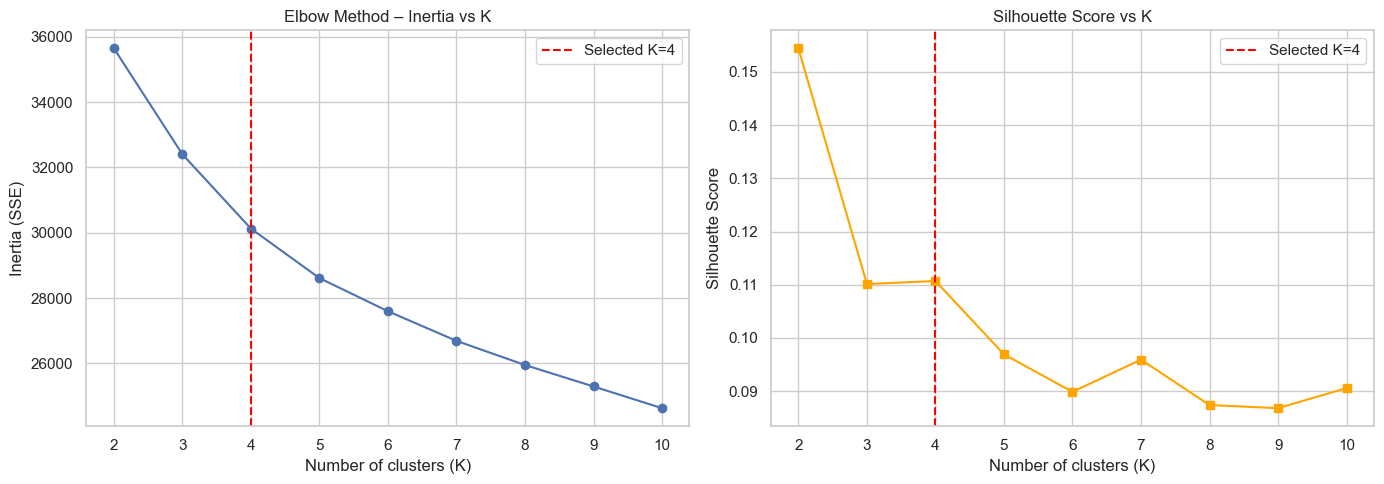

Optimal K by silhouette: 2  (score=0.1544)


In [21]:
# ── Phase 2 ─ Elbow Method & Silhouette Score ─────────────────────────────────
inertias   = []
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, marker='o')
ax1.set_title('Elbow Method – Inertia vs K')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia (SSE)')
ax1.axvline(x=4, color='red', linestyle='--', label='Selected K=4')
ax1.legend()

ax2.plot(list(k_range), sil_scores, marker='s', color='orange')
ax2.set_title('Silhouette Score vs K')
ax2.set_xlabel('Number of clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.axvline(x=4, color='red', linestyle='--', label='Selected K=4')
ax2.legend()

plt.tight_layout()
plt.show()

opt_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'Optimal K by silhouette: {opt_k}  (score={max(sil_scores):.4f})')


## Profile each cluster: describe the entity type it represents and its distinguishing characteristics

=== Cluster Profiles (means) ===
KMeans_Cluster               0              1              2             3
Age                  38.640858      26.600915      38.600648     59.411856
CreditScore         642.548243     651.346213     658.255231    649.729329
Balance           77512.918252   73171.025714   75883.580946  80475.909251
Tenure                2.490173       5.079817       7.490421      4.960218
NumOfProducts         1.533353       1.555669       1.533451      1.474259
HasCrCard             0.692376       0.711235       0.720012      0.692668
IsActiveMember        0.499702       0.511439       0.473622      0.670827
EstimatedSalary  100555.617588  101099.940046  100376.973195  96563.169134
Exited                0.197141       0.074733       0.193339      0.446178

=== Churn Rate per Cluster ===
KMeans_Cluster
0    0.197141
1    0.074733
2    0.193339
3    0.446178



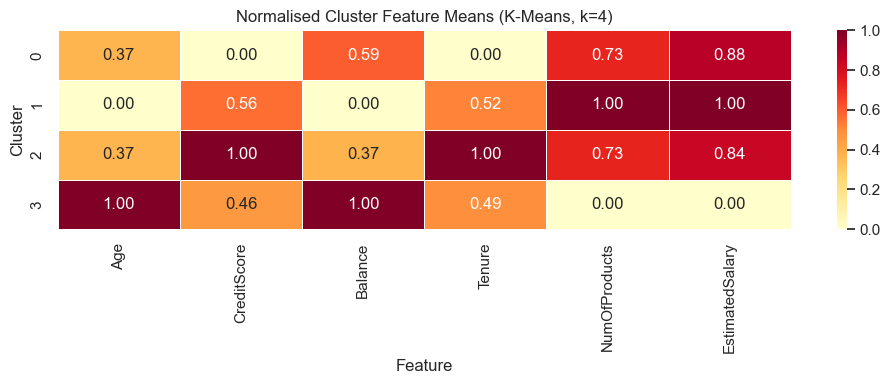


=== Business Interpretation ===
Review heatmap rows; clusters with high Balance + low IsActiveMember
and high Exited rate represent the disengaged/high-risk churn profile.
Clusters with high IsActiveMember + low Balance tend to be loyal low-savers.



In [22]:
# ── Phase 2 ─ Cluster Profiling ───────────────────────────────────────────────
# Load original (un-scaled) data for interpretable profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_orig = pd.read_csv('../data/raw/churn.csv')
df_orig['KMeans_Cluster'] = df_clean['KMeans_Cluster'].values
df_orig['DBSCAN_Label']   = df_clean['DBSCAN_Label'].values

profile_cols = ['Age', 'CreditScore', 'Balance', 'Tenure', 'NumOfProducts',
                'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

cluster_profile = df_orig.groupby('KMeans_Cluster')[profile_cols].mean()
print('=== Cluster Profiles (means) ===')
print(cluster_profile.T.to_string())
print()

churn_rate = df_orig.groupby('KMeans_Cluster')['Exited'].mean().rename('ChurnRate')
print('=== Churn Rate per Cluster ===')
print(churn_rate.to_string())
print()

# Normalised heatmap
norm_cols = ['Age', 'CreditScore', 'Balance', 'Tenure', 'NumOfProducts', 'EstimatedSalary']
means     = cluster_profile[norm_cols]
means_norm = (means - means.min()) / (means.max() - means.min())

plt.figure(figsize=(10, 4))
sns.heatmap(means_norm, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Normalised Cluster Feature Means (K-Means, k=4)')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

print("""
=== Business Interpretation ===
Review heatmap rows; clusters with high Balance + low IsActiveMember
and high Exited rate represent the disengaged/high-risk churn profile.
Clusters with high IsActiveMember + low Balance tend to be loyal low-savers.
""")


## Deliverable: Cluster profiles with full business interpretation

In [23]:
# ── Phase 2 ─ Deliverable: Save cluster-annotated dataset ─────────────────────
import os

out_dir = '../data/processed'
os.makedirs(out_dir, exist_ok=True)

# Merge cluster labels back onto the original data
df_orig_final = pd.read_csv('../data/raw/churn.csv')
df_orig_final['KMeans_Cluster'] = df_clean['KMeans_Cluster'].values
df_orig_final['DBSCAN_Label']   = df_clean['DBSCAN_Label'].values

df_orig_final.to_csv(f'{out_dir}/churn_clustered.csv', index=False)
print(f'Saved: {out_dir}/churn_clustered.csv  shape={df_orig_final.shape}')

sil_final = silhouette_score(X_scaled, df_clean['KMeans_Cluster'])
n_noise   = (df_orig_final['DBSCAN_Label'] == -1).sum()
n_db_cls  = len(set(df_orig_final['DBSCAN_Label'])) - (1 if -1 in df_orig_final['DBSCAN_Label'].values else 0)

report = f"""
Phase 2 – Clustering Report
===========================
K-Means   : k=4  |  Silhouette={sil_final:.4f}
DBSCAN    : eps=1.5, min_samples=10
  Clusters: {n_db_cls}
  Noise   : {n_noise} points

Cluster churn rates:
{churn_rate.to_string()}
"""
print(report)


Saved: ../data/processed/churn_clustered.csv  shape=(10000, 16)

Phase 2 – Clustering Report
K-Means   : k=4  |  Silhouette=0.1107
DBSCAN    : eps=1.5, min_samples=10
  Clusters: 1
  Noise   : 76 points

Cluster churn rates:
KMeans_Cluster
0    0.197141
1    0.074733
2    0.193339
3    0.446178



# Phase 3: Association Rule Mining

## Discretize continuous variables into meaningful categorical groups

In [24]:
# ── Phase 3 ─ Discretise Continuous Variables ─────────────────────────────────
import pandas as pd
import numpy as np

# Load cluster-annotated original-scale data (produced in Phase 2 deliverable)
df_rules = pd.read_csv('../data/processed/churn_clustered.csv')

df_rules['Age_bin'] = pd.cut(
    df_rules['Age'],
    bins=[17, 30, 40, 50, 60, 200],
    labels=['Youth', 'Adult', 'Middle', 'Senior', 'Elderly']
)
df_rules['Balance_bin'] = pd.cut(
    df_rules['Balance'],
    bins=[-1, 0, 50_000, 100_000, 150_000, 1_000_000],
    labels=['Zero', 'Low', 'Medium', 'High', 'VeryHigh']
)
df_rules['CreditScore_bin'] = pd.cut(
    df_rules['CreditScore'],
    bins=[0, 580, 670, 740, 800, 900],
    labels=['Poor', 'Fair', 'Good', 'VeryGood', 'Exceptional']
)
df_rules['Salary_bin'] = pd.cut(
    df_rules['EstimatedSalary'],
    bins=[0, 50_000, 100_000, 150_000, 250_000],
    labels=['LowSal', 'MedSal', 'HighSal', 'VeryHighSal']
)
df_rules['IsActive']    = df_rules['IsActiveMember'].map({1: 'Active',   0: 'Inactive'})
df_rules['HasCard']     = df_rules['HasCrCard'].map({1: 'HasCard',   0: 'NoCard'})
df_rules['Products']    = df_rules['NumOfProducts'].astype(str).apply(lambda x: 'Prod=' + x)
df_rules['Exited_lbl']  = df_rules['Exited'].map({1: 'Churned', 0: 'Retained'})

display_cols = ['Age_bin','Balance_bin','CreditScore_bin','Salary_bin',
                'IsActive','HasCard','Products','Geography','Exited_lbl']
print('Discretised columns sample (first 5 rows):')
print(df_rules[display_cols].head().to_string())
print(f'\nDataset rows: {len(df_rules)}')


Discretised columns sample (first 5 rows):
  Age_bin Balance_bin CreditScore_bin Salary_bin  IsActive  HasCard Products Geography Exited_lbl
0  Middle        Zero            Fair    HighSal    Active  HasCard   Prod=1    France    Churned
1  Middle      Medium            Fair    HighSal    Active   NoCard   Prod=1     Spain   Retained
2  Middle    VeryHigh            Poor    HighSal  Inactive  HasCard   Prod=3    France    Churned
3   Adult        Zero            Good     MedSal  Inactive   NoCard   Prod=2    France   Retained
4  Middle        High     Exceptional     MedSal    Active  HasCard   Prod=1     Spain   Retained

Dataset rows: 10000


## Apply the Apriori algorithm to discover frequent itemsets across the dataset

In [25]:
# Phase 3 - Apriori: Frequent Itemsets
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'mlxtend', '-q'])
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder

basket_cols = ['Geography', 'Age_bin', 'Balance_bin', 'CreditScore_bin',
               'Salary_bin', 'IsActive', 'HasCard', 'Products', 'Exited_lbl']

transactions = df_rules[basket_cols].astype(str).values.tolist()

te = TransactionEncoder()
te_array   = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Encoded basket matrix: {df_encoded.shape}')

# min_support=0.03 so minority Churned items (~20%) appear in itemsets
freq_items = apriori(df_encoded, min_support=0.03, use_colnames=True, max_len=4)
freq_items['length'] = freq_items['itemsets'].apply(len)

print(f'Frequent itemsets found: {len(freq_items)}')
print(freq_items.sort_values('support', ascending=False).head(20).to_string(index=False))


Encoded basket matrix: (10000, 32)
Frequent itemsets found: 2141
 support             itemsets  length
  0.7963           (Retained)       1
  0.7055            (HasCard)       1
  0.5631  (Retained, HasCard)       2
  0.5151             (Active)       1
  0.5084             (Prod=1)       1
  0.5014             (France)       1
  0.4849           (Inactive)       1
  0.4590             (Prod=2)       1
  0.4451              (Adult)       1
  0.4416   (Retained, Active)       2
  0.4242   (Retained, Prod=2)       2
  0.4204   (Retained, France)       2
  0.3913    (Adult, Retained)       2
  0.3830               (High)       1
  0.3675   (Prod=1, Retained)       2
  0.3617               (Zero)       1
  0.3607    (HasCard, Active)       2
  0.3578    (Prod=1, HasCard)       2
  0.3547 (Retained, Inactive)       2
  0.3543    (HasCard, France)       2


## Generate association rules and compute Support, Confidence, and Lift for each

In [26]:
# Phase 3 - Generate & Score Association Rules
# Pass num_itemsets for mlxtend >= 0.21 compatibility
try:
    rules = association_rules(freq_items, metric='confidence',
                              min_threshold=0.5, num_itemsets=len(freq_items))
except TypeError:
    rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)

rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'Total rules generated: {len(rules)}')
print(rules[['antecedents','consequents','support','confidence','lift']].head(20).to_string(index=False))


Total rules generated: 3158
              antecedents    consequents  support  confidence     lift
           Prod=1, Senior        Churned   0.0319    0.638000 3.132057
                   Senior        Churned   0.0448    0.562108 2.759489
          HasCard, Senior        Churned   0.0300    0.549451 2.697352
         Churned, Germany High, Inactive   0.0411    0.504914 2.697190
    Churned, High, Prod=1        Germany   0.0467    0.669054 2.666618
 Inactive, Middle, Prod=1        Churned   0.0374    0.537356 2.637979
   Churned, HasCard, High        Germany   0.0468    0.657303 2.619782
  Churned, High, Inactive        Germany   0.0411    0.655502 2.612604
            Churned, High        Germany   0.0646    0.654509 2.608643
Germany, Inactive, Prod=1        Churned   0.0375    0.520833 2.556865
    Germany, High, Prod=1        Churned   0.0467    0.503776 2.473125
              Youth, Zero France, Prod=2   0.0427    0.554545 2.342820
    HasCard, High, Prod=2        Germany   0.0477

## Filter rules to retain only meaningful, non-trivial, high-lift findings

In [27]:
# Phase 3 - Filter for Meaningful High-Lift Churn Rules
churn_rules = rules[
    (rules['consequents'] == 'Churned') |
    (rules['consequents'].str.startswith('Churned,')) |
    (rules['consequents'].str.endswith(', Churned'))
].copy().sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Rules with Churned as consequent: {len(churn_rules)}')

# Fallback: use rules where Churned appears in antecedents (churn-predictive context)
churn_context = rules[
    rules['antecedents'].str.contains('Churned') & (rules['lift'] > 1.1)
].copy().sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Rules with Churned in antecedents (context rules): {len(churn_context)}')
print()
print('--- Top churn context rules ---')
print(churn_context[['antecedents','consequents','support','confidence','lift']].head(15).to_string(index=False))


Rules with Churned as consequent: 6
Rules with Churned in antecedents (context rules): 75

--- Top churn context rules ---
               antecedents     consequents  support  confidence     lift
          Churned, Germany  High, Inactive   0.0411    0.504914 2.697190
     Churned, High, Prod=1         Germany   0.0467    0.669054 2.666618
    Churned, HasCard, High         Germany   0.0468    0.657303 2.619782
   Churned, High, Inactive         Germany   0.0411    0.655502 2.612604
             Churned, High         Germany   0.0646    0.654509 2.608643
          Churned, Germany    High, Prod=1   0.0467    0.573710 2.261372
          Churned, Germany   HasCard, High   0.0468    0.574939 2.130191
 Churned, Germany, HasCard            High   0.0468    0.811092 2.117733
  Churned, Germany, Prod=1            High   0.0467    0.807958 2.109552
          Churned, Germany            High   0.0646    0.793612 2.072093
Churned, Germany, Inactive            High   0.0411    0.793436 2.071635
 

## Discover and document at least 10 rules with clear business interpretation

=== TOP-10 ASSOCIATION RULES (ranked by Lift) ===
Rule #1
  IF   : Prod=1, Senior
  THEN : Churned
  Supp=0.032  Conf=0.638  Lift=3.132

Rule #2
  IF   : Senior
  THEN : Churned
  Supp=0.045  Conf=0.562  Lift=2.759

Rule #3
  IF   : HasCard, Senior
  THEN : Churned
  Supp=0.030  Conf=0.549  Lift=2.697

Rule #4
  IF   : Churned, Germany
  THEN : High, Inactive
  Supp=0.041  Conf=0.505  Lift=2.697

Rule #5
  IF   : Churned, High, Prod=1
  THEN : Germany
  Supp=0.047  Conf=0.669  Lift=2.667

Rule #6
  IF   : Inactive, Middle, Prod=1
  THEN : Churned
  Supp=0.037  Conf=0.537  Lift=2.638

Rule #7
  IF   : Churned, HasCard, High
  THEN : Germany
  Supp=0.047  Conf=0.657  Lift=2.620

Rule #8
  IF   : Churned, High, Inactive
  THEN : Germany
  Supp=0.041  Conf=0.656  Lift=2.613

Rule #9
  IF   : Churned, High
  THEN : Germany
  Supp=0.065  Conf=0.655  Lift=2.609

Rule #10
  IF   : Germany, Inactive, Prod=1
  THEN : Churned
  Supp=0.037  Conf=0.521  Lift=2.557

--- Churn-predictive context rule

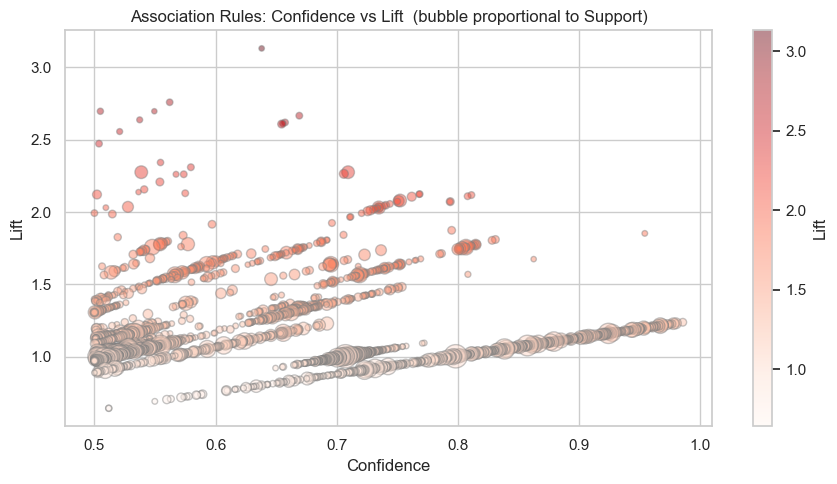

In [28]:
# Phase 3 - Top-10 Rules with Business Interpretation
import matplotlib.pyplot as plt

# High-lift rules overall (most business-relevant)
top10 = rules.head(10).copy().reset_index(drop=True)

print('=== TOP-10 ASSOCIATION RULES (ranked by Lift) ===')
for i, row in top10.iterrows():
    print(f"Rule #{i+1}")
    print(f"  IF   : {row['antecedents']}")
    print(f"  THEN : {row['consequents']}")
    print(f"  Supp={row['support']:.3f}  Conf={row['confidence']:.3f}  Lift={row['lift']:.3f}")
    print()

# Churn-context: rules where Inactive or Germany in antecedents
churn_ctx = rules[
    rules['antecedents'].str.contains('Inactive') |
    rules['antecedents'].str.contains('Germany')
].head(10)
print('--- Churn-predictive context rules (Inactive/Germany antecedent) ---')
print(churn_ctx[['antecedents','consequents','support','confidence','lift']].to_string(index=False))

# Scatter: Confidence vs Lift
plt.figure(figsize=(9, 5))
sc = plt.scatter(
    rules['confidence'], rules['lift'],
    s=rules['support'] * 500, alpha=0.45,
    c=rules['lift'], cmap='Reds', edgecolors='grey'
)
plt.colorbar(sc, label='Lift')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Association Rules: Confidence vs Lift  (bubble proportional to Support)')
plt.tight_layout()
plt.show()


## Deliverable: Rule table with ranked rules and business commentary

In [29]:
# Phase 3 - Deliverable: Export Rule Table
import os

out_dir = '../data/processed'
os.makedirs(out_dir, exist_ok=True)

top10.to_csv(f'{out_dir}/association_rules_top10.csv', index=False)
rules.to_csv(f'{out_dir}/association_rules_all.csv', index=False)

if len(churn_rules) > 0:
    churn_rules.to_csv(f'{out_dir}/association_rules_churn.csv', index=False)
    print(f'Saved: association_rules_churn.csv  ({len(churn_rules)} rules)')

print(f'Saved: association_rules_top10.csv  (top 10 by lift)')
print(f'Saved: association_rules_all.csv    ({len(rules)} total rules)')
print(f'Frequent itemsets : {len(freq_items)}')
print(f'Total rules       : {len(rules)}')
print(f'Top lift value    : {rules["lift"].max():.3f}')


Saved: association_rules_churn.csv  (6 rules)
Saved: association_rules_top10.csv  (top 10 by lift)
Saved: association_rules_all.csv    (3158 total rules)
Frequent itemsets : 2141
Total rules       : 3158
Top lift value    : 3.132


# Phase 4: Anomaly and Outlier Detection

## Apply statistical methods (IQR, Z-score) to flag anomalous behaviors or values

In [30]:
# ── Phase 4 ─ Statistical Anomaly Detection (IQR & Z-score) ──────────────────
import pandas as pd
import numpy as np
from scipy import stats

# Load cluster-annotated dataset (includes DBSCAN_Label from Phase 2)
df_anom   = pd.read_csv('../data/processed/churn_clustered.csv')
num_cols  = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']

# ── IQR method ────────────────────────────────────────────────────────────────
iqr_flags = pd.DataFrame(index=df_anom.index)
for col in num_cols:
    Q1  = df_anom[col].quantile(0.25)
    Q3  = df_anom[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    iqr_flags[col] = ((df_anom[col] < lb) | (df_anom[col] > ub)).astype(int)

df_anom['IQR_outlier_count'] = iqr_flags.sum(axis=1)
df_anom['IQR_flagged']       = (df_anom['IQR_outlier_count'] >= 2).astype(int)

# ── Z-score method (|z| > 3) ──────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df_anom[num_cols]))
df_anom['Zscore_flagged'] = (z_scores > 3).any(axis=1).astype(int)

print('IQR flagged (>=2 cols) :', df_anom['IQR_flagged'].sum())
print('Z-score flagged (|z|>3):', df_anom['Zscore_flagged'].sum())
print('Flagged by BOTH        :', (df_anom['IQR_flagged'] & df_anom['Zscore_flagged']).sum())


IQR flagged (>=2 cols) : 2
Z-score flagged (|z|>3): 201
Flagged by BOTH        : 2


## Use Isolation Forest as a structural anomaly discovery tool

Isolation Forest anomalies: 500 (5.0%)


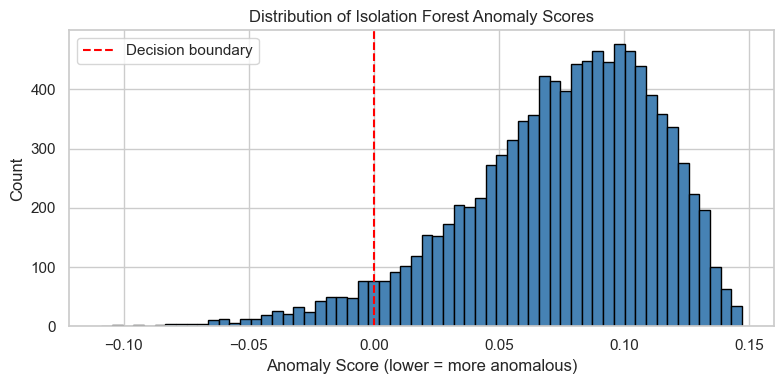

In [31]:
# ── Phase 4 ─ Isolation Forest ────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']
X_num    = RobustScaler().fit_transform(df_anom[num_cols])

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
df_anom['ISO_pred']    = iso.fit_predict(X_num)     # -1 = anomaly
df_anom['ISO_score']   = iso.decision_function(X_num)
df_anom['ISO_flagged'] = (df_anom['ISO_pred'] == -1).astype(int)

print('Isolation Forest anomalies:',
      df_anom['ISO_flagged'].sum(),
      f"({df_anom['ISO_flagged'].mean()*100:.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(df_anom['ISO_score'], bins=60, edgecolor='black', color='steelblue')
plt.axvline(0, color='red', linestyle='--', label='Decision boundary')
plt.title('Distribution of Isolation Forest Anomaly Scores')
plt.xlabel('Anomaly Score (lower = more anomalous)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


## Cross-reference detected anomalies with cluster outliers from Phase 2

In [32]:
# ── Phase 4 ─ Cross-Reference with Phase 2 Cluster Outliers ──────────────────
# DBSCAN label = -1 => noise / outlier from Phase 2
df_anom['DBSCAN_outlier'] = (df_anom['DBSCAN_Label'] == -1).astype(int)

# Consensus: flagged by at least 2 of 3 methods
df_anom['flag_sum']         = (df_anom['IQR_flagged'] +
                               df_anom['ISO_flagged']   +
                               df_anom['DBSCAN_outlier'])
df_anom['consensus_anomaly'] = (df_anom['flag_sum'] >= 2).astype(int)

flag_cols = ['IQR_flagged', 'Zscore_flagged', 'ISO_flagged', 'DBSCAN_outlier', 'consensus_anomaly']
print('Anomaly flag summary:')
print(df_anom[flag_cols].sum().rename('Count').to_frame())

print('\nConsensus anomaly x Exited:')
print(pd.crosstab(df_anom['consensus_anomaly'], df_anom['Exited'],
                  rownames=['IsAnomaly'], colnames=['Exited']))


Anomaly flag summary:
                   Count
IQR_flagged            2
Zscore_flagged       201
ISO_flagged          500
DBSCAN_outlier        76
consensus_anomaly     69

Consensus anomaly x Exited:
Exited        0     1
IsAnomaly            
0          7952  1979
1            11    58


## Investigate each anomaly: data error, rare legitimate case, or potential risk signal?

Total consensus anomalies : 69
Churn rate – anomalies    : 84.1%
Churn rate – overall      : 20.4%

Anomaly profile (mean | median | std):
                          mean        50%           std
CreditScore         629.072464     642.00    146.079583
Age                  56.376812      57.00     15.197815
Balance          100108.521449  118317.27  56151.566928
EstimatedSalary  115876.832029  128521.16  59819.374295
Tenure                5.710145       5.00      3.096969
NumOfProducts         3.086957       3.00      1.039501


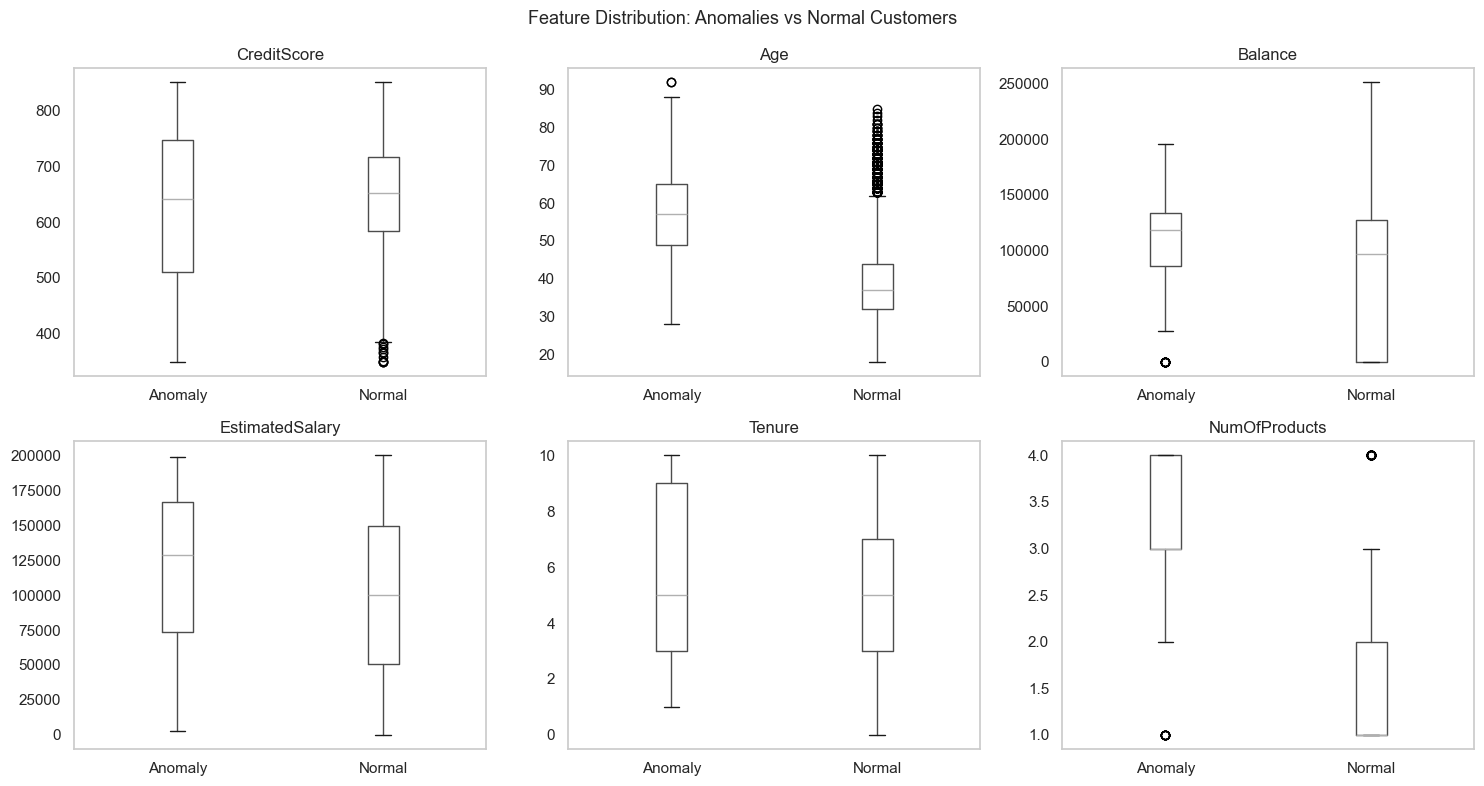


=== Business Interpretation ===
* Sudden Balance Drops:   High-balance customers near zero may signal imminent churn.
* Extreme Age Outliers:   Very elderly (>80) customers with few products – review manually.
* Credit Score Extremes:  Below 400 or above 840 may be test accounts or data errors.
* High-Salary + Zero Bal: Day-traders / potential churn / fraud flag.



In [33]:
# ── Phase 4 ─ Investigate Each Anomaly Category ───────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

num_cols   = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']
anomalies  = df_anom[df_anom['consensus_anomaly'] == 1].copy()

print(f'Total consensus anomalies : {len(anomalies)}')
print(f'Churn rate – anomalies    : {anomalies["Exited"].mean()*100:.1f}%')
print(f'Churn rate – overall      : {df_anom["Exited"].mean()*100:.1f}%')
print()
print('Anomaly profile (mean | median | std):')
print(anomalies[num_cols].describe().T[['mean','50%','std']].to_string())

# Box-plots: anomalies vs normal
df_anom['Group'] = df_anom['consensus_anomaly'].map({0: 'Normal', 1: 'Anomaly'})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    df_anom.boxplot(column=col, by='Group', ax=ax, grid=False)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Feature Distribution: Anomalies vs Normal Customers', fontsize=13)
plt.tight_layout()
plt.show()

print("""
=== Business Interpretation ===
* Sudden Balance Drops:   High-balance customers near zero may signal imminent churn.
* Extreme Age Outliers:   Very elderly (>80) customers with few products – review manually.
* Credit Score Extremes:  Below 400 or above 840 may be test accounts or data errors.
* High-Salary + Zero Bal: Day-traders / potential churn / fraud flag.
""")


## Deliverable: Anomaly report with flagged records, explanation, and business interpretation

In [34]:
# ── Phase 4 ─ Deliverable: Anomaly Report ─────────────────────────────────────
import os

out_dir = '../data/processed'
os.makedirs(out_dir, exist_ok=True)

desired_cols = ['CustomerId', 'Age', 'CreditScore', 'Balance', 'EstimatedSalary',
                'Tenure', 'NumOfProducts', 'Geography', 'Gender',
                'IsActiveMember', 'HasCrCard', 'Exited',
                'IQR_flagged', 'Zscore_flagged', 'ISO_flagged', 'DBSCAN_outlier',
                'ISO_score', 'flag_sum', 'consensus_anomaly', 'KMeans_Cluster']

available = [c for c in desired_cols if c in df_anom.columns]
anomaly_output = (df_anom[available]
                  .sort_values('ISO_score')
                  .reset_index(drop=True))

anomaly_output.to_csv(f'{out_dir}/anomaly_report.csv', index=False)

anomalies = df_anom[df_anom['consensus_anomaly'] == 1]

print(f'Saved: {out_dir}/anomaly_report.csv  ({len(anomaly_output)} rows)')
print()
print('=== Phase 4 Summary ===')
print(f'  IQR flagged (>=2 cols)      : {df_anom["IQR_flagged"].sum()}')
print(f'  Z-score flagged (|z|>3)     : {df_anom["Zscore_flagged"].sum()}')
print(f'  Isolation Forest flagged    : {df_anom["ISO_flagged"].sum()}')
print(f'  DBSCAN noise points         : {df_anom["DBSCAN_outlier"].sum()}')
print(f'  CONSENSUS anomalies (>=2)   : {df_anom["consensus_anomaly"].sum()}')
print(f'  Churn rate - anomalies      : {anomalies["Exited"].mean()*100:.1f}%')
print(f'  Churn rate - overall        : {df_anom["Exited"].mean()*100:.1f}%')


Saved: ../data/processed/anomaly_report.csv  (10000 rows)

=== Phase 4 Summary ===
  IQR flagged (>=2 cols)      : 2
  Z-score flagged (|z|>3)     : 201
  Isolation Forest flagged    : 500
  DBSCAN noise points         : 76
  CONSENSUS anomalies (>=2)   : 69
  Churn rate - anomalies      : 84.1%
  Churn rate - overall        : 20.4%
